In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns
import plotly.express as px

In [2]:
# Load compressed dataset (gzip used to reduce file size for GitHub)

df = pd.read_csv("sf_crime_2003_2025.csv.gz")

In [3]:
# Parse time and create columns

# Convert datetime column
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

# Drop rows where datetime failed
df = df.dropna(subset=["datetime"])

# Extract time information
df["hour"] = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.dayofweek   # Monday=0, Sunday=6
df["is_weekend"] = df["dayofweek"] >= 5

# Optional readable label
df["day_type"] = df["is_weekend"].map({False: "Weekday", True: "Weekend"})

# Check result
print(df[["datetime", "hour", "dayofweek", "day_type"]].head())

             datetime  hour  dayofweek day_type
0 2005-07-23 16:40:00    16          5  Weekend
1 2016-03-03 19:30:00    19          3  Weekday
2 2013-02-10 18:09:00    18          6  Weekend
3 2006-09-25 22:15:00    22          0  Weekday
4 2008-05-23 12:10:00    12          4  Weekday


In [4]:
# which crime categories exist

crime_counts = df["crime"].value_counts()
print(crime_counts)

crime
Theft            751478
Assault          211203
Vandalism        180679
Vehicle Theft    153460
Burglary         141776
Drug Offense     106574
Robbery           74288
Weapons           25061
Name: count, dtype: int64


In [5]:
# Parse datetime
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df = df.dropna(subset=["datetime"])

# Create time features
df["hour"] = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.dayofweek
df["day_type"] = df["dayofweek"].apply(lambda x: "Weekend" if x >= 5 else "Weekday")

# Pick a few crime types
selected_crimes = ["Theft", "Assault", "Burglary"]

df_selected = df[df["crime"].isin(selected_crimes)].copy()

In [6]:
# Compute normalized hourly proportions

hourly_counts = (
    df_selected
    .groupby(["day_type", "crime", "hour"])
    .size()
    .reset_index(name="count")
)

hourly_counts["proportion"] = (
    hourly_counts
    .groupby(["day_type", "crime"])["count"]
    .transform(lambda x: x / x.sum())
)

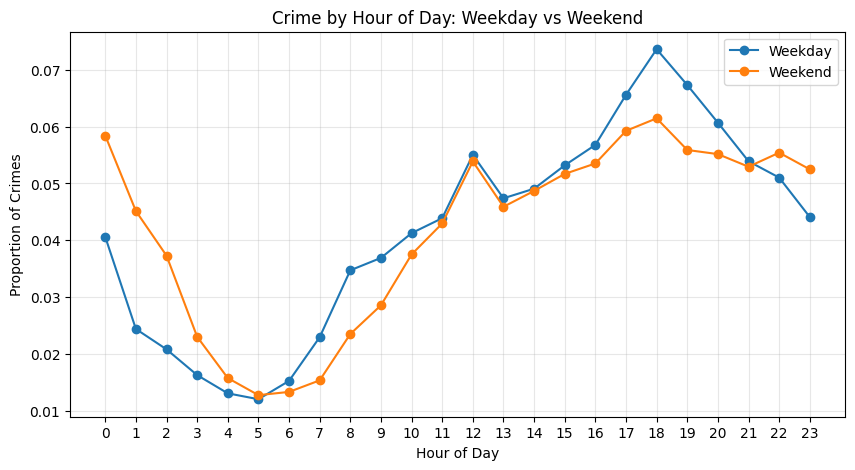

In [7]:
# Plot: total crime by hour, weekday vs weekend

hourly_total = (
    df.groupby(["day_type", "hour"])
      .size()
      .reset_index(name="count")
)

# Normalize within each day_type
hourly_total["proportion"] = (
    hourly_total.groupby("day_type")["count"]
    .transform(lambda x: x / x.sum())
)

plt.figure(figsize=(10, 5))

for day_type in ["Weekday", "Weekend"]:
    subset = hourly_total[hourly_total["day_type"] == day_type]
    plt.plot(subset["hour"], subset["proportion"], marker="o", label=day_type)

plt.title("Crime by Hour of Day: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Proportion of Crimes")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Main analysis: crime type by hour, split by weekday/weekend

selected_crimes = ["Theft", "Assault", "Burglary"]

df_selected = df[df["crime"].isin(selected_crimes)].copy()

hourly_crime = (
    df_selected.groupby(["crime", "day_type", "hour"])
    .size()
    .reset_index(name="count")
)

# Normalize within each crime + day_type
hourly_crime["proportion"] = (
    hourly_crime.groupby(["crime", "day_type"])["count"]
    .transform(lambda x: x / x.sum())
)

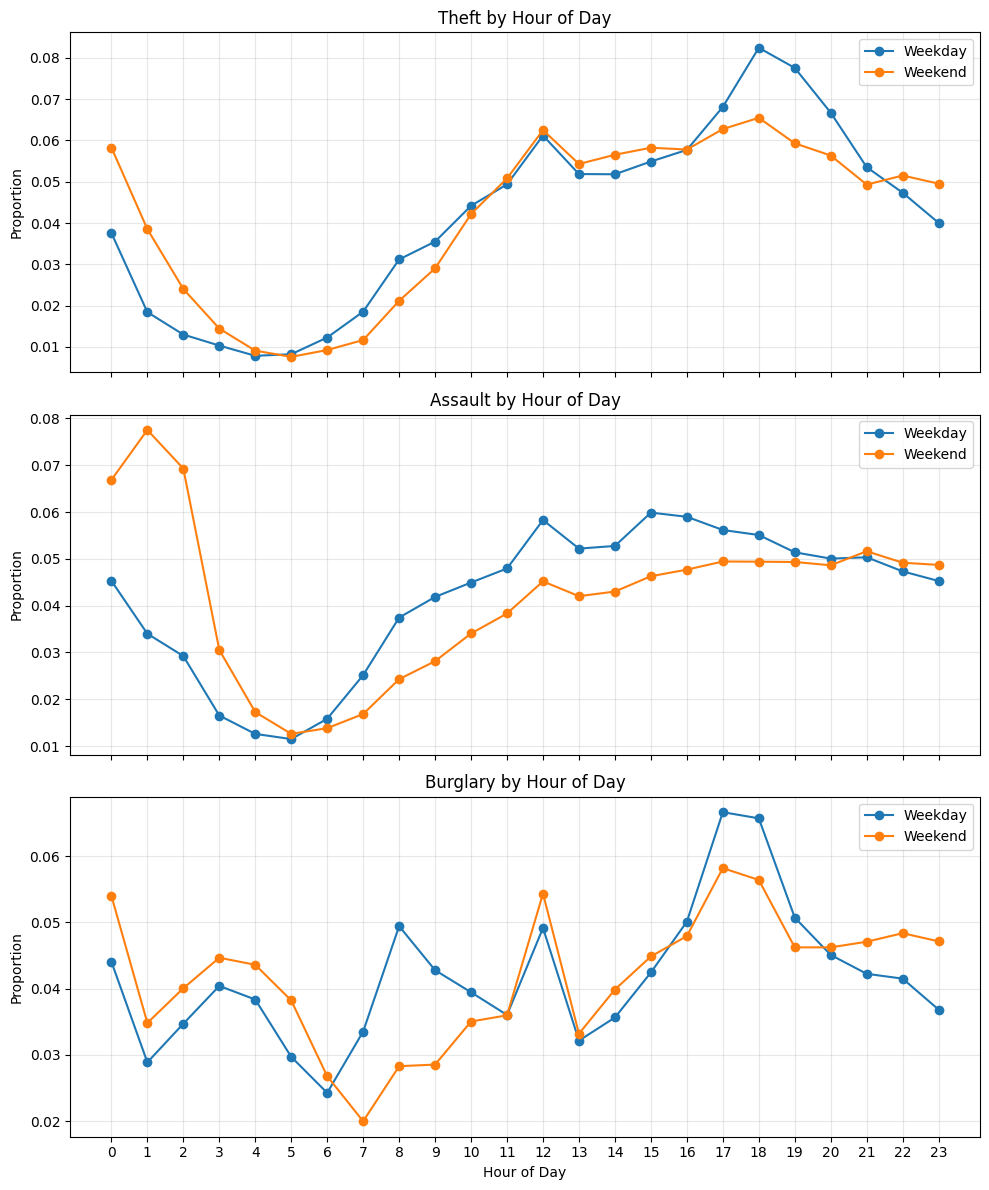

In [9]:
# Plot

fig, axes = plt.subplots(len(selected_crimes), 1, figsize=(10, 12), sharex=True)

for i, crime_type in enumerate(selected_crimes):
    ax = axes[i]
    subset = hourly_crime[hourly_crime["crime"] == crime_type]
    
    for day_type in ["Weekday", "Weekend"]:
        line_data = subset[subset["day_type"] == day_type]
        ax.plot(line_data["hour"], line_data["proportion"], marker="o", label=day_type)
    
    ax.set_title(f"{crime_type} by Hour of Day")
    ax.set_ylabel("Proportion")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Hour of Day")
axes[-1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

In [10]:
# Compare with a day vs night view

def day_night_label(hour):
    if 6 <= hour < 18:
        return "Day"
    else:
        return "Night"

df_selected["time_period"] = df_selected["hour"].apply(day_night_label)

In [11]:
daynight_summary = (
    df_selected.groupby(["crime", "day_type", "time_period"])
    .size()
    .reset_index(name="count")
)

daynight_summary["proportion"] = (
    daynight_summary.groupby(["crime", "day_type"])["count"]
    .transform(lambda x: x / x.sum())
)

print(daynight_summary)

       crime day_type time_period   count  proportion
0    Assault  Weekday         Day   80400    0.551421
1    Assault  Weekday       Night   65405    0.448579
2    Assault  Weekend         Day   28060    0.429065
3    Assault  Weekend       Night   37338    0.570935
4   Burglary  Weekday         Day   52847    0.501704
5   Burglary  Weekday       Night   52488    0.498296
6   Burglary  Weekend         Day   16510    0.453061
7   Burglary  Weekend       Night   19931    0.546939
8      Theft  Weekday         Day  285855    0.536806
9      Theft  Weekday       Night  246656    0.463194
10     Theft  Weekend         Day  113068    0.516370
11     Theft  Weekend       Night  105899    0.483630


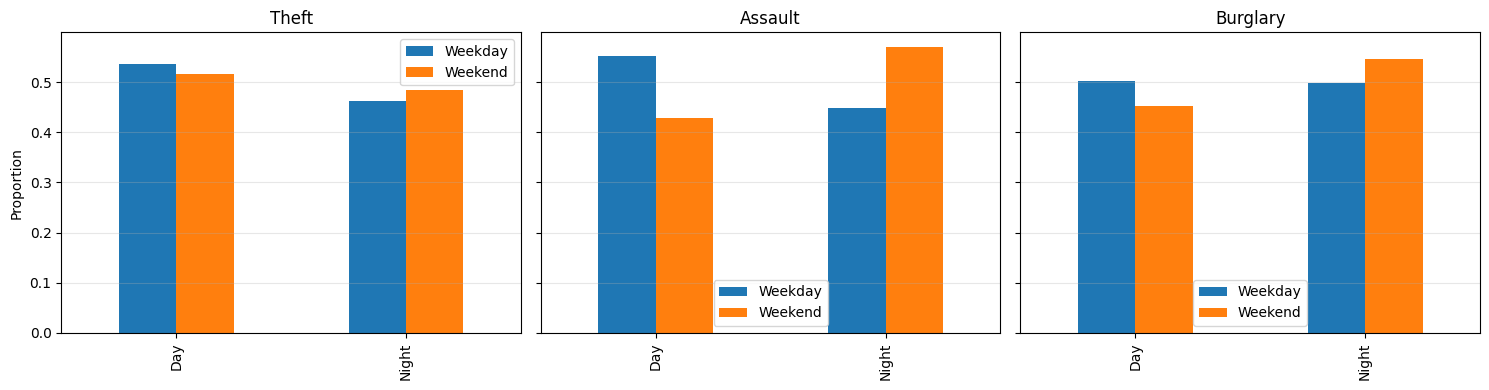

In [12]:
# Plot

fig, axes = plt.subplots(1, len(selected_crimes), figsize=(15, 4), sharey=True)

for i, crime_type in enumerate(selected_crimes):
    ax = axes[i]
    subset = daynight_summary[daynight_summary["crime"] == crime_type]
    
    pivot = subset.pivot(index="time_period", columns="day_type", values="proportion")
    pivot = pivot.loc[["Day", "Night"]]
    pivot.plot(kind="bar", ax=ax)
    
    ax.set_title(crime_type)
    ax.set_xlabel("")
    ax.set_ylabel("Proportion")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="")

plt.tight_layout()
plt.show()

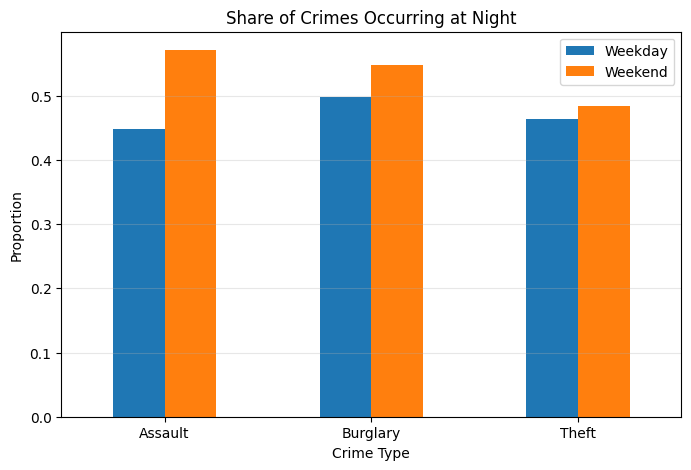

In [13]:
# Keep only night values
night_data = daynight_summary[daynight_summary["time_period"] == "Night"]

# Pivot for plotting
pivot = night_data.pivot(index="crime", columns="day_type", values="proportion")

# Plot
pivot.plot(kind="bar", figsize=(8, 5))

plt.title("Share of Crimes Occurring at Night")
plt.ylabel("Proportion")
plt.xlabel("Crime Type")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="")

plt.show()

In [14]:
# Find peak hours

peak_hours = (
    hourly_crime.loc[hourly_crime.groupby(["crime", "day_type"])["proportion"].idxmax()]
    [["crime", "day_type", "hour", "proportion"]]
    .sort_values(["crime", "day_type"])
)

print(peak_hours)

        crime day_type  hour  proportion
15    Assault  Weekday    15    0.059881
25    Assault  Weekend     1    0.077541
65   Burglary  Weekday    17    0.066654
89   Burglary  Weekend    17    0.058204
114     Theft  Weekday    18    0.082447
138     Theft  Weekend    18    0.065489


In [15]:
# Weekday interactive plot

weekday_data = hourly_counts[hourly_counts["day_type"] == "Weekday"]

fig_weekday = px.bar(
    weekday_data,
    x="hour",
    y="proportion",
    color="crime",
    barmode="overlay",
    opacity=0.65,
    title="Hourly Crime Patterns on Weekdays",
    labels={
        "hour": "Hour of Day",
        "proportion": "Normalized share of crimes",
        "crime": "Crime Type"
    }
)

# Start with all traces hidden
fig_weekday.update_traces(visible="legendonly")

# Fix axes so they make sense even when traces are hidden
fig_weekday.update_layout(
    xaxis=dict(
        tickmode="linear",
        tick0=0,
        dtick=1,
        range=[-0.5, 23.5]
    ),
    yaxis=dict(
        range=[0, 0.09]
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    )
)

fig_weekday.show()

In [16]:
# Weekend interactive plot

weekend_data = hourly_counts[hourly_counts["day_type"] == "Weekend"]

fig_weekend = px.bar(
    weekend_data,
    x="hour",
    y="proportion",
    color="crime",
    barmode="overlay",
    opacity=0.65,
    title="Hourly Crime Patterns on Weekends",
    labels={
        "hour": "Hour of Day",
        "proportion": "Normalized share of crimes",
        "crime": "Crime Type"
    }
)

fig_weekend.update_traces(visible="legendonly")

fig_weekend.update_layout(
    xaxis=dict(
        tickmode="linear",
        tick0=0,
        dtick=1,
        range=[-0.5, 23.5]
    ),
    yaxis=dict(
        range=[0, 0.09]
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    )
)

fig_weekend.show()